In [1]:
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [13]:
cls_1 = df[df['pclass'] == 1]['fare']
cls_2 = df[df['pclass'] == 2]['fare']
cls_3 = df[df['pclass'] == 3]['fare']
f_stat, p_val = st.f_oneway(cls_1, cls_2, cls_3)
print(f'F-stat: {f_stat:.4f}')
print(f'p-value: {p_val}')

F-stat: 242.3442
p-value: 1.031376320913912e-84


In [14]:
import pandas as pd
import statsmodels.stats.multicomp as sm

tukey = sm.pairwise_tukeyhsd(endog=df['fare'], groups=df['pclass'], alpha=0.05)
print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
     1      2 -63.4925   0.0 -72.9165 -54.0685   True
     1      3 -70.4791   0.0 -78.1489 -62.8094   True
     2      3  -6.9866 0.108 -15.1064   1.1331  False
-----------------------------------------------------


In [17]:
male = df[df['sex'] == 'male']['fare']
female = df[df['sex'] == 'female']['fare']
u_stat, p_val = st.mannwhitneyu(male, female)
print(f'U-stat: {u_stat:.4f}', f'P-value: {p_val}')

U-stat: 62175.0000 P-value: 9.61232696290926e-15


<Axes: xlabel='fare', ylabel='Count'>

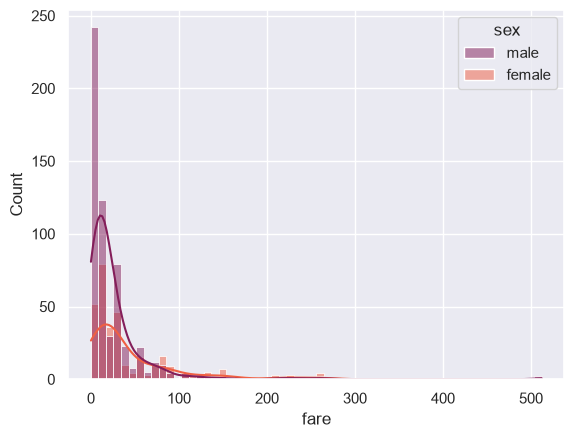

In [20]:
sns.set_theme(style='darkgrid')
sns.histplot(data=df, x='fare', hue='sex', kde=True, palette='rocket')